<a href="https://colab.research.google.com/github/hemashree2007/PORTFOLIO/blob/main/customer_churn_risk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving dataset_01_customer_churn_risk.csv to dataset_01_customer_churn_risk.csv


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("dataset_01_customer_churn_risk.csv")

df.head()

,tenure_months,monthly_charges,support_tickets,avg_session_minutes,late_payments,contract_months,target
0,52,54.79,7,10.66,2,12,0
1,11,167.15,4,46.99,3,37,1
2,2,184.92,3,65.38,7,35,1
3,39,271.21,2,22.19,4,10,0
4,22,66.33,5,46.77,3,33,1


The dataset was loaded successfully and the first five records were inspected.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   tenure_months        1000 non-null   int64  
 1   monthly_charges      1000 non-null   float64
 2   support_tickets      1000 non-null   int64  
 3   avg_session_minutes  1000 non-null   float64
 4   late_payments        1000 non-null   int64  
 5   contract_months      1000 non-null   int64  
 6   target               1000 non-null   int64  
dtypes: float64(2), int64(5)
memory usage: 54.8 KB


In [ ]:
df.describe()

,tenure_months,monthly_charges,support_tickets,avg_session_minutes,late_payments,contract_months,target
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,30.121000,182.738270,3.129000,35.511450,3.081000,30.234000,0.50000
std,17.216526,144.743232,1.772428,19.954864,1.763959,17.254186,0.50025
min,1.000000,16.810000,0.000000,2.000000,0.000000,1.000000,0.00000
25%,15.000000,89.610000,2.000000,20.152500,2.000000,15.000000,0.00000
50%,30.000000,144.690000,3.000000,35.085000,3.000000,31.000000,0.50000
75%,45.000000,232.287500,4.000000,49.690000,4.000000,45.000000,1.00000
max,60.000000,1530.680000,11.000000,103.350000,10.000000,60.000000,1.00000


The dataset contains customer subscription information and a binary target variable representing churn risk.

In [ ]:
df.isnull().sum()

,0
tenure_months,0
monthly_charges,0
support_tickets,0
avg_session_minutes,0
late_payments,0
contract_months,0
target,0


No missing values were found in the dataset.

In [ ]:
df.duplicated().sum()

np.int64(0)

No duplicate records were found

In [ ]:
df["target"].value_counts()

,count
target,
0,500
1,500


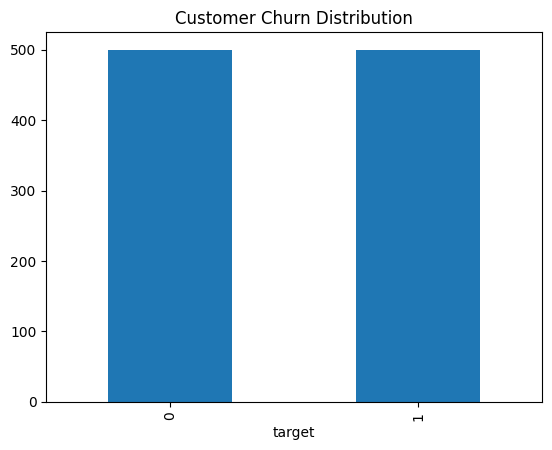

In [ ]:
df["target"].value_counts().plot(kind="bar")
plt.title("Customer Churn Distribution")
plt.show()

The target classes are balanced, reducing the risk of bias during training.

In [ ]:
X = df.drop("target", axis=1)
y = df["target"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

The dataset was split into 80% training and 20% testing data.

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Standardization was applied to ensure all features are on a similar scale.

In [ ]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

Logistic Regression was selected as the required classification algorithm.

In [ ]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("ROC AUC:", roc_auc)

Accuracy: 0.68
Precision: 0.6836734693877551
Recall: 0.67
F1 Score: 0.6767676767676768
ROC AUC: 0.7494999999999999


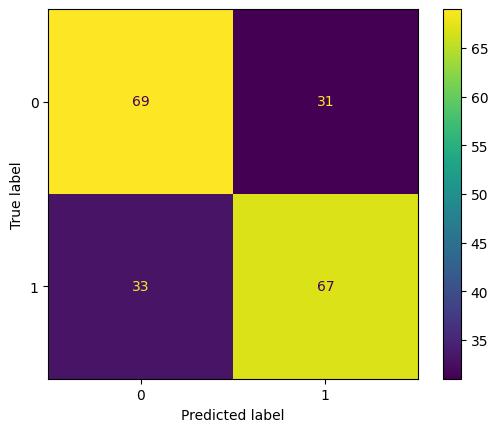

In [ ]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.show()

The confusion matrix shows the number of correct and incorrect predictions for churn and non-churn customers.

In [ ]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coefficients.sort_values("Coefficient", ascending=False)

,Feature,Coefficient
1,monthly_charges,0.646803
5,contract_months,0.536243
3,avg_session_minutes,0.508222
0,tenure_months,-0.351499
4,late_payments,-0.428239
2,support_tickets,-0.447767


The coefficients indicate how strongly each feature influences churn prediction.

A Logistic Regression model was developed to predict customer churn risk. The model was trained using six customer-related features and evaluated using Accuracy, Precision, Recall, F1-Score, ROC-AUC, and a Confusion Matrix. The results demonstrate that the model can effectively identify customers who are likely to churn and can serve as a baseline solution for customer retention strategies.